# Inference des architectures U-Net
- U-Net avec encodeur ResNet34
- ResAttentionUNetPlusPlus
- Attention Gated Multi ResU-Net
- CSANet

In [ ]:
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from matplotlib.colors import LinearSegmentedColormap

import pickle 

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des fonctions utilitaires
from utils.models_config import collate_fn_sequence, collate_fn, split_dataset, dataset_to_dict, metrics_by_class
from utils.unet_spatial import unpad_array
from utils.stats_fct import overlay_mask, mask_to_yolo_polygons, plot_segmentation_comparison
from utils.post_traitement import keep_largest_components, fill_holes, split_eggs

# Importation des architectures de modèles
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.AttentionMultiResUNet import AttentionMultiResUNet
from models.CSANet import CSANet
from models.EggSegmentationHVUNet import (EggSegmentationHVUNet, EggSegmentationHVLoss, postprocess_egg_instances)

/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reproductibilité du code

In [2]:
# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### =========== Choix du modèle ===========

In [ ]:
MODEL_NAME = "UNet" # UNet, AttentionUNet++, MultiResUnet, EggSegmentationHVUNet ou CSANet

### =========== Choix des données ===========

In [9]:
DATASET_NAME = "oeufs"  # "3classes" ou "2classses" ou "oeufs"

### Importation et traitement des données

In [ ]:
# -------- 1. Importation des images et annotations --------
DATASET_CONFIG = {
    "2classes": {"images": "../data/images/cavite", "annotations": "../data/labels/COCO/cavite/annotations_2_classes.json"},
    "3classes": {"images": "../data/images/cavite", "annotations": "../data/labels/COCO/cavite/annotations.json"},
    "oeufs": {"images": "../data/images/oeufs", "annotations": "../data/labels/COCO/oeufs/annotations.oeufs.json"},
}
images_dir = DATASET_CONFIG[DATASET_NAME]["images"]
annotations_json = DATASET_CONFIG[DATASET_NAME]["annotations"]

IS_SEQUENCE = True if MODEL_NAME in ["CSANet"] else False  # True pour les modèles 2,5D séquentiels (csanet)
dim = "2.5" if IS_SEQUENCE else "2"

results_dir = f"results/test/{MODEL_NAME}"
masks_dir = f"masks/test/{MODEL_NAME}"

# ------- 2. Importation du Data Frame avec les metadata --------
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# -------- 3. Préparation du dataset --------
# Transformation du dataset en dictionnaire et récupération des informations nécessaires pour l'entraînement et l'évaluation
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, images_dir)

# Gestion de la classe "Ignore Gonade" si présente dans le dataset
gonade_id = class_ids.index(next((cid for cid, name in categories.items() if name == "Gonade"), class_ids[0])) if ignore_category_id is not None else None

class_names = [categories[cid] for cid in class_ids]
print(f"Model : {MODEL_NAME}, Dataset : {DATASET_NAME}, classes={class_names}")

Classes détectées (1) : {2: 'Oeuf'}
Model : UNet, Dataset : oeufs, classes=['Oeuf']


### Division du jeu de données

In [11]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test, cv_dataset, test_dataset = split_dataset(all_samples, images_dir, df, IMAGE_SIZE, num_classes, 
                                                                                                                              class_ids, 
                                                                                                                              dim=dim, # dim = "2" car images 2D
                                                                                                                              ignore_category_id=ignore_category_id, # ID de la classe "Ignore" si présente
                                                                                                                              ignore_target_class_idx=gonade_id) # ID de la classe "Gonade" si présente
print(f"Shape des images: {test_dataset[0]['image'].shape}")

Nombre total d'images valides : 69
Échantillons train/val        : 57
Échantillons de test          : 12
Shape des images: torch.Size([3, 512, 512])


### Cross validation

In [ ]:
# ---- Cross validation k-folds ----
k_folds = 5
kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)
X = np.array(cv_samples, dtype=object) # Les images

# --- Echelle en cm par image ---
echelle_cm_by_image = {}
for sample in test_samples:
    id_image = sample["image_info"]["file_name"].split("_")[0]
    echelle_rows = df.loc[df["image_id"] == id_image, "echelle"]
    if echelle_rows.empty:
        raise ValueError(f"Échelle introuvable pour l'image {id_image}")
    echelle_cm_by_image[id_image] = float(echelle_rows.iloc[0])

### Chargement du modèle

In [ ]:
# --- Crée le dossier de résultats s'il n'existe pas ---
os.makedirs(results_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nb_channels = cv_dataset[0]['image'].shape[0]  # Nombre de canaux d'entrée

# --- Création du jeu de test ---
test_loader = DataLoader(
    test_dataset,
    batch_size=1 if IS_SEQUENCE else 4,
    shuffle=False,
    collate_fn=collate_fn_sequence if IS_SEQUENCE else collate_fn,
)

# --- Chargement des 5 folds selon MODEL_NAME et DATASET_NAME ---
models_ensemble = []
for fold in range(1, 6):
    if MODEL_NAME == "UNet":
        m = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", # resnet34 ou efficientnet-b5
            in_channels=nb_channels, classes=num_classes, activation=None,)
    elif MODEL_NAME == "CSANet":
        m = CSANet(num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet")
    elif MODEL_NAME == "AttentionUNet++":
        m = ResAttentionUNetPlusPlus(num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet")
    elif MODEL_NAME == "MultiResUNet":
        m = AttentionMultiResUNet(num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet")
    elif MODEL_NAME == "EggSegmentationHVUNet":
        if DATASET_NAME != "oeufs":
            raise ValueError("EggSegmentationHVUNet nécessite DATASET_NAME='oeufs'")
        m = EggSegmentationHVUNet(in_channels=nb_channels, encoder_weights="imagenet")
        
    m.load_state_dict(torch.load(f"saves/unet_finetuned_fold_{fold}_{MODEL_NAME}_{DATASET_NAME}.pth", map_location=device))
    m.to(device)
    m.eval()
    models_ensemble.append(m)

### Initialisation des métriques

In [18]:
# Seuil d'attribution des pixels aux classes
threshold = 0.5

# Stockage des métriques par image
count = 0
iou_list = []
precision_list = []
recall_list = []
dice_list = []
diff_surface_list = []
ratio_surface_list = []

# Stockages des métriques cumulées par classe
total_iou_per_class = np.zeros(num_classes)
total_intersection_per_class = np.zeros(num_classes)
total_union_per_class = np.zeros(num_classes)
total_pred_surface_per_class = np.zeros(num_classes)
total_true_surface_per_class = np.zeros(num_classes)
total_diff_surface_per_class = np.zeros(num_classes)
total_ratio_surface_per_class = np.zeros(num_classes)

## Sauvegarde des prédictions et calcul des métriques

In [ ]:
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        # -------- 1. Normalisation du batch  + noms de fichiers ------
        if IS_SEQUENCE:
            images = batch['image'].to(device)                  # (1, T, C, H, W) - entrée modèle
            images_disp = images.squeeze(0)                     # (T, C, H, W) - pour affichage/sauvegarde
            true_masks = batch['mask'].to(device).squeeze(0)    # (T, num_classes, H, W)
            metric_file_names = [os.path.basename(p) for p in batch['image_path'][0]]
            file_names_batch = [fn.split("j")[0] for fn in metric_file_names]
        else:
            images = batch['image'].to(device)                  # (B, C, H, W)
            images_disp = images
            true_masks = batch['mask'].to(device)
            metric_file_names = batch['file_names']
            file_names_batch = [fn.split("j")[0] for fn in metric_file_names]

        N = images_disp.size(0)

        # -------- 2. Prédiction du modèle ---------
        ensemble_probs = torch.zeros((N, num_classes, IMAGE_SIZE[0], IMAGE_SIZE[1])).to(device)

        for m in models_ensemble:
            outputs = m(images)
            if IS_SEQUENCE:
                outputs = outputs.squeeze(0)
            ensemble_probs += torch.sigmoid(outputs)
        # Faire la moyenne
        ensemble_probs = ensemble_probs / len(models_ensemble)

        # valid_mask exclut les pixels marqués -100 (zones "ignore")
        valid_mask = true_masks != -100

        # Appliquer le seuil
        true_bool = (true_masks > threshold) & valid_mask
        pred_masks = (ensemble_probs > threshold) & valid_mask

        # --- Appliquer le post-processing ---
        if DATASET_NAME == "oeufs":
            if MODEL_NAME == "EggSegmentationHVUNet":
                # Post-traitement spécifique pour le modèle EggSegmentationHVUNet
                preds_masks = postprocess_egg_instances(pred_masks)
            preds_masks = split_eggs(pred_masks, min_distance=8, min_area=100, ouverture_size=3, ouverture_iterations=1)

        else:
            pred_masks = keep_largest_components(pred_masks)
            pred_masks = fill_holes(pred_masks)
            pred_masks = pred_masks & valid_mask

        # --------- 3. Calcul des métriques par image et par classe ---------
        echelle_batch = torch.tensor(
            [echelle_cm_by_image[fn.split("_")[0]] for fn in metric_file_names],
            device=device, dtype=torch.float32,
        ).view(-1, 1)
        intersection, union, iou_per_img, dice_per_img, precision_per_img, recall_per_img, diff_surface = metrics_by_class(
            true_bool, pred_masks, echelle_batch, DATASET_NAME
        )

        # metrics_by_class ne renvoie pas le ratio de surface : on le conserve comme métrique additionnelle.
        true_surface = true_bool.float().sum((2, 3))
        pred_surface = pred_masks.float().sum((2, 3))
        ratio_surface = (true_surface - pred_surface).abs() / (true_surface + 1e-6)
         
        # --- Ajouter les métriques à leurs listes ---
        for i in range(N):
            iou_list.append(iou_per_img[i].cpu().numpy())
            precision_list.append(precision_per_img[i].cpu().numpy())
            recall_list.append(recall_per_img[i].cpu().numpy())
            dice_list.append(dice_per_img[i].cpu().numpy())
            diff_surface_list.append(diff_surface[i].cpu().numpy())
            ratio_surface_list.append(ratio_surface[i].cpu().numpy())

        # Cumuler pour le calcul final par classe (dim=0)
        total_iou_per_class += iou_per_img.sum(dim=0).cpu().numpy()
        total_intersection_per_class += intersection.sum(dim=0).cpu().numpy()
        total_union_per_class += union.sum(dim=0).cpu().numpy()
        total_pred_surface_per_class += pred_surface.sum(dim=0).cpu().numpy()
        total_true_surface_per_class += true_surface.sum(dim=0).cpu().numpy()
        total_diff_surface_per_class += diff_surface.sum(dim=0).cpu().numpy()
        total_ratio_surface_per_class += ratio_surface.sum(dim=0).cpu().numpy()

        count += N
        
        for i in range(images_disp.size(0)):
            # ------- 4. Sauvegarde de chaque image avec superposition des masques --------
            true_display = overlay_mask(images_disp[i], true_masks[i], alpha=0.4, target_size = (510,380))
            pred_display = overlay_mask(images_disp[i], pred_masks[i], alpha=0.4, target_size = (510,380))

            # Créer l'image combinée côte à côte : [prédiction | vrai]
            combined_img = np.hstack((true_display, pred_display))

            # Récupèrer le nom de l'image
            file_name = file_names_batch[i]

            # Sauvegarder l'image combinée
            Image.fromarray(combined_img).save(f"{results_dir}/{file_name}_{batch_idx}_img{i}.png")

            # -------- 5. sauvegarde des masques au format YOLO ---------
            # Créer les fichiers .txt contenant les chemins
            pred_txt = f'{masks_dir}/pred_{file_name}txt'

            # Écriture du fichier pour les prédictions
            # Les masques 512x512 sont dépaddés avant l'export dans le référentiel cropé.
            with open(pred_txt, 'w') as f_pred:
                for class_idx in range(num_classes):
                    #pred_mask_np = (pred_masks[i, class_idx].cpu().numpy() * 255).astype(np.uint8)
                    polygons = mask_to_yolo_polygons(unpad_array(pred_masks[i,class_idx]), class_idx, target_size=(510, 380))
                    if polygons:
                        f_pred.write('\n'.join(polygons) + '\n')


IndexError: index 1 is out of bounds for axis 1 with size 1

### Affichage d'une image

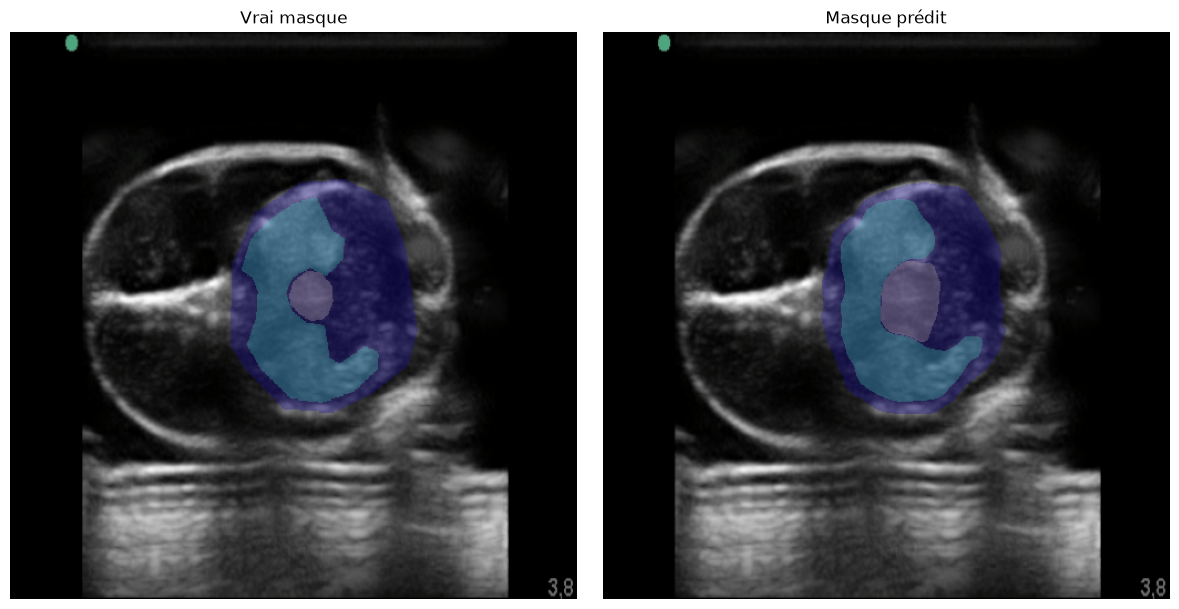

In [27]:
threshold = 0.5
idx = 0  # index de la coupe à afficher dans le batch

# -------- 1. Récupérer une image d'un batch --------
data_iterator = iter(test_loader)
sample_batch1 = next(data_iterator)
sample_batch = next(data_iterator)

if IS_SEQUENCE:
    sample_images_disp = sample_batch['image'].squeeze(0)              # (T, C, H, W) - pour affichage
    sample_input = sample_batch['image'].to(device)                    # (1, T, C, H, W) - séquence complète, entrée modèle
    true_mask = sample_batch['mask'].squeeze(0)[idx]                    # (num_classes, H, W)
    n_slices = sample_images_disp.size(0)
else:
    sample_images_disp = sample_batch['image']                        # (B, C, H, W)
    sample_input = sample_batch['image'][idx].unsqueeze(0).to(device)  # (1, C, H, W)
    true_mask = sample_batch['mask'][idx]
    n_slices = 1

# -------- 2. Récupérer les prédictions de l'image --------
with torch.no_grad():
    ensemble_probs_full = torch.zeros((n_slices, num_classes, IMAGE_SIZE[0], IMAGE_SIZE[1])).to(device)
    for m in models_ensemble:
            outputs = m(sample_input)
            if IS_SEQUENCE:
                outputs = outputs.squeeze(0)  # (1, T, num_classes, H, W) -> (T, num_classes, H, W)
            ensemble_probs_full += torch.sigmoid(outputs)
    # Faire la moyenne sur les folds
    ensemble_probs_full = ensemble_probs_full / len(models_ensemble)

    ensemble_probs = ensemble_probs_full[idx if IS_SEQUENCE else 0].unsqueeze(0)
    pred_mask = (ensemble_probs[0] > threshold).float().cpu()

# -------- 3. Affichage de l'image et des masques --------
plot_segmentation_comparison(
    sample_images_disp[idx],
    true_mask,
    pred_mask,
    is_eggs=DATASET_NAME == "oeufs",
    alpha=0.3,
)

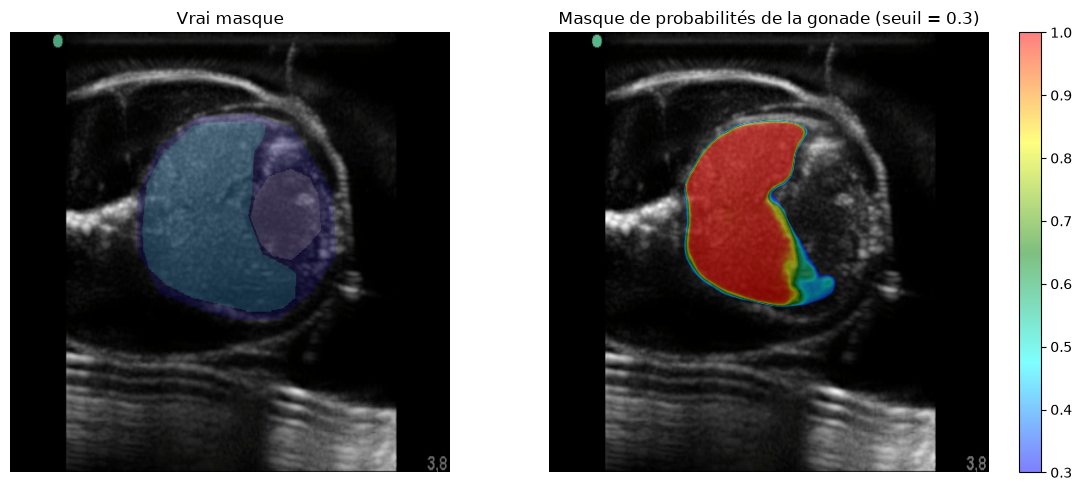

In [10]:
# -------- Paramètres --------
threshold = 0.3  # Seuil pour ignorer les pixels < 0.3
classe_cible = 1  # Classe à visualiser

# -------- Récupérer les probabilités --------
probs_classe_1 = ensemble_probs[0, classe_cible].cpu().numpy()  # Shape: (H, W)

# -------- Créer la colormap (bleu -> rouge) --------
colors = ["blue", "cyan", "green", "yellow", "red"]
cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=256)

# -------- Masquer les pixels sous le seuil --------
# Les pixels < threshold seront totalement ignorés par Matplotlib
probs_masked = np.ma.masked_where(probs_classe_1 < threshold, probs_classe_1)

# -------- Image originale (normalisée) --------
sample_image_np = sample_images_disp[idx].cpu().numpy()
if sample_image_np.shape[0] == 3:  # Format (C, H, W) -> (H, W, C)
    sample_image_np = np.transpose(sample_image_np, (1, 2, 0))
sample_image_np = (sample_image_np - sample_image_np.min()) / (sample_image_np.max() - sample_image_np.min())

# -------- Affichage --------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vrai Masque
true_display = overlay_mask(sample_images_disp[idx], true_mask, alpha=0.2)
axes[0].imshow(true_display)
axes[0].set_title("Vrai masque")
axes[0].axis('off')

# 1. Afficher d'abord l'image d'origine en fond
axes[1].imshow(sample_image_np)

# 2. Superposer la carte de probabilité masquée avec de la transparence (alpha)
im = axes[1].imshow(probs_masked, cmap=cmap, vmin=threshold, vmax=1, alpha=0.5)

# 3. Lier la colorbar à l'objet 'im'
cbar = plt.colorbar(
    im,
    ax=axes[1],
    ticks=np.arange(threshold, 1.1, 0.1),
)

axes[1].set_title(f"Masque de probabilités de la gonade (seuil = {threshold})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Résultats, métriques et sauvegarde

In [11]:
# --- Affichage performances finales ---
if count > 0:
    # Calculs globaux sur tout le dataset
    mean_iou_per_class = total_iou_per_class / count
    dataset_iou_per_class = total_intersection_per_class / (total_union_per_class + 1e-6)
    
    precision_per_class = total_intersection_per_class / (total_pred_surface_per_class + 1e-6)
    recall_per_class = total_intersection_per_class / (total_true_surface_per_class + 1e-6)
    dice_per_class = 2 * total_intersection_per_class / (total_pred_surface_per_class + total_true_surface_per_class + 1e-6)
    false_positive_per_class = total_pred_surface_per_class - total_intersection_per_class
    false_negative_per_class = total_true_surface_per_class - total_intersection_per_class

    mean_diff_surface_per_class = total_diff_surface_per_class / count
    mean_ratio_surface_per_class = total_ratio_surface_per_class / count
    
    print("\n" + "="*60)
    print("--- PERFORMANCES PAR CLASSE SUR LE DATASET DE TEST ---")
    print("="*60)
    
    for idx, cat_id in enumerate(class_ids):
        # Si categories est un dict, ajustez selon votre implémentation.
        class_name = categories[cat_id] 
        print(f"Classe : {class_name.upper()}")
        print(f"  -> IoU (Moyenne) : {mean_iou_per_class[idx]:.4f}")
        print(f"  -> IoU (Cumulée) : {dataset_iou_per_class[idx]:.4f}")
        print(f"  -> Précision     : {precision_per_class[idx]:.4f}")
        print(f"  -> Rappel        : {recall_per_class[idx]:.4f}")
        print(f"  -> Dice / F1     : {dice_per_class[idx]:.4f}")
        print(f"  -> Différence surfaces (moyenne) : {mean_diff_surface_per_class[idx]:.4f} cm²")
        print(f"  -> Ratio surfaces (moyenne)     : {mean_ratio_surface_per_class[idx]:.4f}")
        print(f"  -> [Pixels] TP: {int(total_intersection_per_class[idx])} | FP: {int(false_positive_per_class[idx])} | FN: {int(false_negative_per_class[idx])}")
        print("-" * 60)
        
    print(f"\n=> Mean IoU globale (mIoU)  : {mean_iou_per_class.mean():.4f}")
    print(f"=> IoU globale cumulée      : {total_intersection_per_class.sum() / (total_union_per_class.sum() + 1e-6):.4f}")
    print(f"=> Dice / F1 global (mDice) : {dice_per_class.mean():.4f}")
else:
    print("Aucune image testée.")

### Résultats par images du jeu de test

In [14]:
[x["image_info"]["file_name"] for x in test_samples]

['0004572_10.29.35_356302_2019.jpg',
 '0004573_10.30.05_356302_2019.jpg',
 '0004574_10.30.33_356302_2019.jpg',
 '0004672_12.18.23_356948_2019.jpg',
 '0004673_12.18.32_356948_2019.jpg',
 '0004674_12.18.40_356948_2019.jpg',
 '0004675_12.18.49_356948_2019.jpg',
 '0006926_09.44.56_426687_2024.jpg',
 '0006928_09.45.51_426687_2024.jpg',
 '0006929_09.46.01_426687_2024.jpg',
 '0007138_10.27.57_427242_2024.jpg',
 '0007140_10.43.46_427266_2024.jpg',
 '0007141_10.43.56_427266_2024.jpg',
 '0007142_10.44.03_427266_2024.jpg',
 '0007143_10.44.12_427266_2024.jpg']

In [15]:
iou_gonade = []
ratio_gonade = []
dice_list_gonade = []
diff_surface_gonade = []
for i in range(len(iou_list)):
    iou_gonade.append(f"{iou_list[i][1]:.3f}")
    ratio_gonade.append(f"{ratio_surface_list[i][1]:.3f}")
    dice_list_gonade.append(f"{dice_list[i][1]:.3f}")
    diff_surface_gonade.append(f"{diff_surface_list[i][1]:.3f}")

print("------- IOU GONADE -------")
print(iou_gonade)
print(f"Min : {min(iou_gonade)}")
print(f"Max : {max(iou_gonade)}")

print("------- DIFF SURFACES GONADE EN CM2-------")
print(diff_surface_gonade)
print(f"Min : {min(diff_surface_gonade)}")
print(f"Max : {max(diff_surface_gonade)}")

print("------- RATIO DIFF SURFACES GONADE -------")
print(ratio_gonade)
print(f"Min : {min(ratio_gonade)}")
print(f"Max : {max(ratio_gonade)}")

print("------- DICE / F1 GONADE -------")
print(dice_list_gonade)
print(f"Min : {min(dice_list_gonade)}")
print(f"Max : {max(dice_list_gonade)}")


### Sauvegarder les résultats

In [14]:
iou_categories = {'all_iou': iou_gonade, 
               'categories': test_categories}

# Sauvegarde des valeurs d'IoU sur le test
with open("saves/categories_test_xlstm.pkl", 'wb') as f:
    pickle.dump(iou_categories, f)